In [43]:
import sys
import os
import numpy as np
import pandas as pd
import pickle
import time

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Add src/ to path so we can import shared utilities
sys.path.append(os.path.join(os.getcwd(), '..', '..'))
from src.preprocessing import apply_smote
from src.evaluation import compute_metrics, plot_confusion_matrix, save_results
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [44]:
# ## 2. DNN Model Architecture

# %%
class IntrusionDetectionDNN(nn.Module):
    """
    Fully connected feedforward network for 13-class classification.

    Architecture:
        Input → 128 → BatchNorm → ReLU → Dropout
              → 64  → BatchNorm → ReLU → Dropout
              → 32  → BatchNorm → ReLU → Dropout
              → 13 (output)

    Input size changes based on feature set (10, 20, 30, 83, or PCA components).
    Output is always 13 (one per class).
    """

    def __init__(self, input_size, num_classes=12, dropout_rate=0.3):
        super(IntrusionDetectionDNN, self).__init__()

        self.network = nn.Sequential(
            # Layer 1: Input → 128
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2: 128 → 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3: 64 → 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output layer: 32 → 13
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Quick test — model should initialize without errors
test_model = IntrusionDetectionDNN(input_size=83)
print(test_model)
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")
del test_model


IntrusionDetectionDNN(
  (network): Sequential(
    (0): Linear(in_features=83, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=12, bias=True)
  )
)

Total parameters: 21,932


In [45]:
# ## 3. Training Utilities

# %%
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size=256):
    """Convert numpy arrays to PyTorch DataLoaders."""
    # Convert to tensors
    X_train_t = torch.FloatTensor(np.array(X_train)).to(device)
    y_train_t = torch.LongTensor(np.array(y_train)).to(device)
    X_test_t = torch.FloatTensor(np.array(X_test)).to(device)
    y_test_t = torch.LongTensor(np.array(y_test)).to(device)

    # Create datasets
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


def compute_class_weights(y_train):
    """
    Compute inverse class frequency weights for cost-sensitive learning.
    Used in CrossEntropyLoss(weight=...) to penalize minority class errors more.

    Example: NMAP_FIN_SCAN (~22 samples) gets a much higher weight than
    DOS_SYN_Hping (~75,000 samples), forcing the model to care about rare attacks.
    """
    classes = np.unique(y_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    weights_tensor = torch.FloatTensor(weights).to(device)

    print("Class weights (higher = rarer class):")
    for cls, w in zip(classes, weights):
        print(f"  Class {cls}: {w:.4f}")


    return weights_tensor
    



In [46]:

# ## 4. Training Loop

# %%
def train_dnn(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    num_epochs=100,
    patience=10,
    model_name="DNN"
):
    """
    Train the DNN with early stopping.

    Args:
        model: IntrusionDetectionDNN instance
        train_loader: training DataLoader
        test_loader: test DataLoader (used for validation/early stopping)
        criterion: loss function (CrossEntropyLoss, with or without weights)
        optimizer: Adam optimizer
        num_epochs: maximum epochs to train
        patience: stop if validation loss doesn't improve for this many epochs
        model_name: string label for logging

    Returns:
        dict with training history (losses per epoch) and best model state
    """
    print(f"\n{'='*60}")
    print(f" Training: {model_name}")
    print(f" Epochs: {num_epochs} | Patience: {patience}")
    print(f"{'='*60}")

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    start_time = time.time()

    for epoch in range(num_epochs):
        # --- Training phase ---
        model.train()
        epoch_train_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
            num_batches += 1

        avg_train_loss = epoch_train_loss / num_batches
        train_losses.append(avg_train_loss)

        # --- Validation phase ---
        model.eval()
        epoch_val_loss = 0.0
        num_val_batches = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                epoch_val_loss += loss.item()
                num_val_batches += 1

        avg_val_loss = epoch_val_loss / num_val_batches
        val_losses.append(avg_val_loss)

        # --- Early stopping check ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        # Print every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

    elapsed = time.time() - start_time
    print(f"  Training time: {elapsed:.1f}s")

    # Load best model
    model.load_state_dict(best_model_state)

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": len(train_losses) - patience_counter,
        "training_time": elapsed,
    }
    

In [47]:

# ## 5. Prediction & Evaluation

# %%
def predict_dnn(model, test_loader):
    """Get predictions from trained model."""
    model.eval()
    all_preds = []

    with torch.no_grad():
        for X_batch, _ in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())

    return np.array(all_preds)


def plot_loss_curves(history, model_name="DNN", save_path=None):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_losses"], label="Train Loss", linewidth=2)
    plt.plot(history["val_losses"], label="Val Loss", linewidth=2)
    plt.axvline(
        x=history["best_epoch"],
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Best Epoch ({history['best_epoch']})"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training & Validation Loss — {model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()



In [48]:

# ## 6. Run All Experiments
#
# This is the main experiment runner.
# It runs DNN across 5 feature sets × 3 imbalance strategies = 15 runs.

# %%
def run_single_experiment(
    X_train, y_train, X_test, y_test,
    feature_set_name, imbalance_strategy,
    target_names=None,
    num_epochs=100, patience=10, lr=0.001, dropout=0.3, batch_size=256
):
    """
    Run one DNN experiment with a specific feature set and imbalance strategy.

    Args:
        X_train, y_train: training data
        X_test, y_test: test data (never modified)
        feature_set_name: e.g., "full-83", "top-10", "pca"
        imbalance_strategy: "baseline", "smote", or "cost-sensitive"
        target_names: list of class names for reporting
    """
    model_name = f"DNN | {feature_set_name} | {imbalance_strategy}"
    print(f"\n{'#'*70}")
    print(f"# Experiment: {model_name}")
    print(f"{'#'*70}")

    # --- Step 1: Apply imbalance strategy ---
    if imbalance_strategy == "smote":
        print("Applying SMOTE to training data...")
        X_train_exp, y_train_exp = apply_smote(X_train, y_train)
    else:
        X_train_exp, y_train_exp = X_train, y_train

    # --- Step 2: Create dataloaders ---
    train_loader, test_loader = create_dataloaders(
        X_train_exp, y_train_exp, X_test, y_test, batch_size=batch_size
    )

    # --- Step 3: Initialize model ---
    input_size = X_train_exp.shape[1]
    model = IntrusionDetectionDNN(
        input_size=input_size,
        num_classes=12,
        dropout_rate=dropout
    ).to(device)

    # --- Step 4: Set up loss function ---
    if imbalance_strategy == "cost-sensitive":
        print("Computing class weights for cost-sensitive learning...")
        class_weights = compute_class_weights(np.array(y_train_exp))
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Step 5: Train ---
    history = train_dnn(
        model, train_loader, test_loader,
        criterion, optimizer,
        num_epochs=num_epochs,
        patience=patience,
        model_name=model_name
    )

    # --- Step 6: Predict & evaluate ---
    y_pred = predict_dnn(model, test_loader)
    results = compute_metrics(y_test, y_pred)

    # Add extra info
    results["feature_set"] = feature_set_name
    results["imbalance_strategy"] = imbalance_strategy
    results["training_time"] = history["training_time"]
    results["history"] = history

    # --- Step 7: Save loss curve ---
    save_path = f"../../figures/dnn_loss_{feature_set_name}_{imbalance_strategy}.png"
    plot_loss_curves(history, model_name=model_name, save_path=save_path)

    # --- Step 8: Save model ---
    model_path = f"../../models/dnn_{feature_set_name}_{imbalance_strategy}.pt"
    torch.save(model.state_dict(), model_path)
    print(f"  Model saved: {model_path}")

    return results


Full feature set: 83 features
Target classes: ['ARP_poisioning', 'DDOS_Slowloris', 'DOS_SYN_Hping', 'MQTT_Publish', 'Metasploit_Brute_Force_SSH', 'NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN', 'Thing_Speak', 'Wipro_bulb']

######################################################################
# Experiment: DNN | full-83 | baseline
######################################################################

 Training: DNN | full-83 | baseline
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.5004 | Val Loss: 0.1038 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0413 | Val Loss: 0.0350 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.0289 | Val Loss: 0.0466 | Patience: 9/10

  Early stopping at epoch 21
  Training time: 12.7s

  Macro F1 (PRIMARY):  0.7909
  Accuracy:            0.9942
  Macro Precision:     0.8116
  Macro Recall:        0.7768

  Saved: ../../figures/dnn_loss_full-83_baseline.png


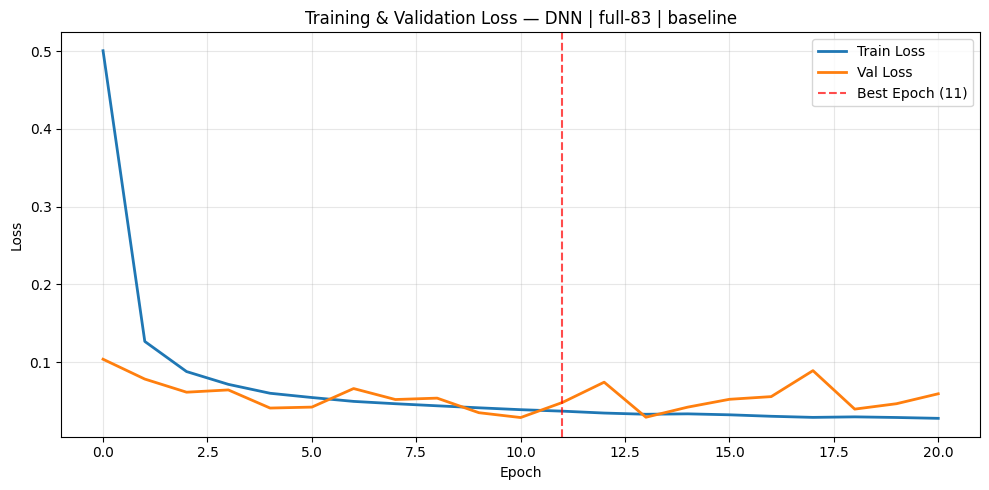

  Model saved: ../../models/dnn_full-83_baseline.pt

######################################################################
# Experiment: DNN | full-83 | smote
######################################################################
Applying SMOTE to training data...
  Before SMOTE: 98,493 samples


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples

 Training: DNN | full-83 | smote
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.1924 | Val Loss: 0.0504 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0484 | Val Loss: 0.1247 | Patience: 6/10

  Early stopping at epoch 14
  Training time: 68.8s

  Macro F1 (PRIMARY):  0.8679
  Accuracy:            0.9944
  Macro Precision:     0.8382
  Macro Recall:        0.9696

  Saved: ../../figures/dnn_loss_full-83_smote.png


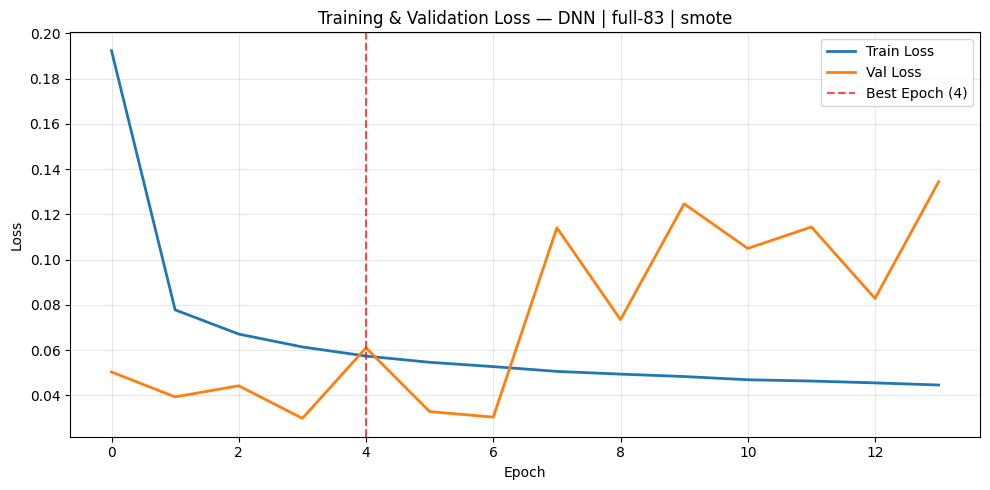

  Model saved: ../../models/dnn_full-83_smote.pt

######################################################################
# Experiment: DNN | full-83 | cost-sensitive
######################################################################
Computing class weights for cost-sensitive learning...
Class weights (higher = rarer class):
  Class 0: 1.3238
  Class 1: 19.2219
  Class 2: 0.1084
  Class 3: 2.4744
  Class 4: 273.5917
  Class 5: 373.0795
  Class 6: 5.1298
  Class 7: 10.2341
  Class 8: 3.9613
  Class 9: 5.1043
  Class 10: 1.2655
  Class 11: 40.6324

 Training: DNN | full-83 | cost-sensitive
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 1.2195 | Val Loss: 0.6748 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.2684 | Val Loss: 0.3330 | Patience: 2/10
  Epoch  20/100 | Train Loss: 0.1962 | Val Loss: 0.2592 | Patience: 0/10
  Epoch  30/100 | Train Loss: 0.1566 | Val Loss: 0.2948 | Patience: 2/10
  Epoch  40/100 | Train Loss: 0.1304 | Val Loss: 0.2377 | Patience: 8/10

  Early 

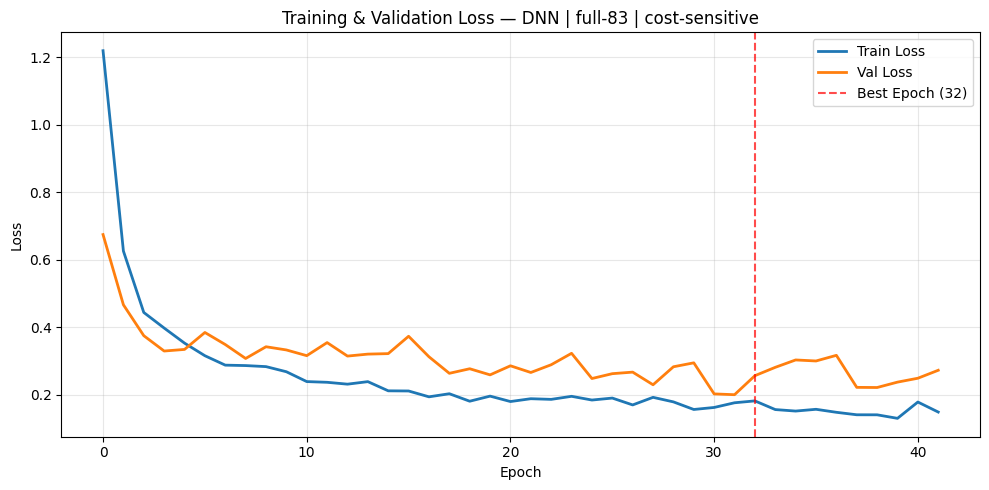

  Model saved: ../../models/dnn_full-83_cost-sensitive.pt

######################################################################
# Experiment: DNN | top-30 | baseline
######################################################################

 Training: DNN | top-30 | baseline
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.5251 | Val Loss: 0.1189 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0447 | Val Loss: 0.0275 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.0339 | Val Loss: 0.0231 | Patience: 1/10
  Epoch  30/100 | Train Loss: 0.0295 | Val Loss: 0.0220 | Patience: 5/10
  Epoch  40/100 | Train Loss: 0.0273 | Val Loss: 0.0189 | Patience: 6/10

  Early stopping at epoch 44
  Training time: 24.0s

  Macro F1 (PRIMARY):  0.8798
  Accuracy:            0.9945
  Macro Precision:     0.8995
  Macro Recall:        0.8637

  Saved: ../../figures/dnn_loss_top-30_baseline.png


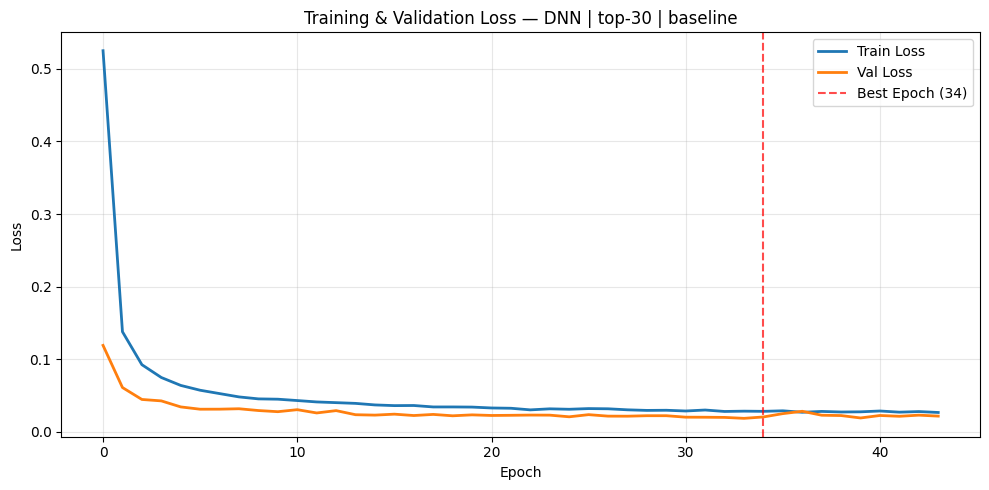

  Model saved: ../../models/dnn_top-30_baseline.pt

######################################################################
# Experiment: DNN | top-30 | smote
######################################################################
Applying SMOTE to training data...
  Before SMOTE: 98,493 samples


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples

 Training: DNN | top-30 | smote
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.2277 | Val Loss: 0.0271 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0632 | Val Loss: 0.0282 | Patience: 1/10

  Early stopping at epoch 19
  Training time: 86.7s

  Macro F1 (PRIMARY):  0.9006
  Accuracy:            0.9950
  Macro Precision:     0.8704
  Macro Recall:        0.9720

  Saved: ../../figures/dnn_loss_top-30_smote.png


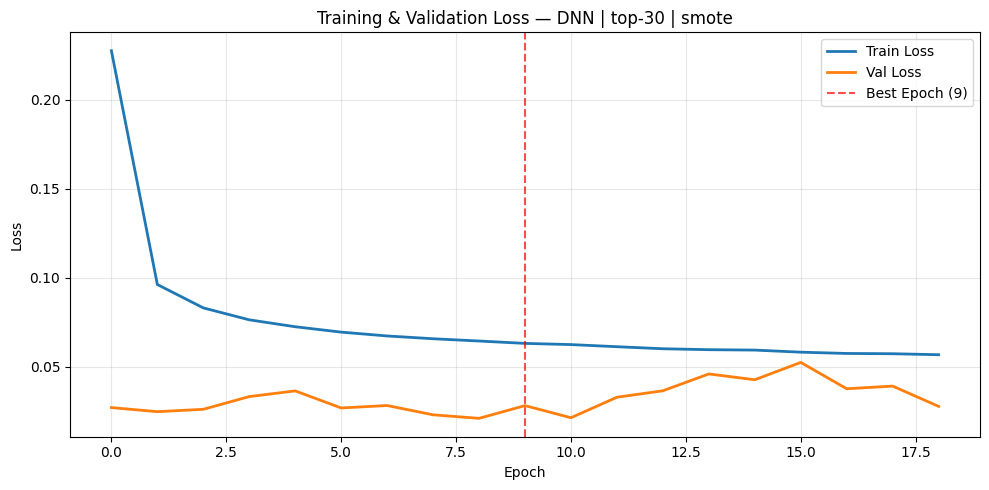

  Model saved: ../../models/dnn_top-30_smote.pt

######################################################################
# Experiment: DNN | top-30 | cost-sensitive
######################################################################
Computing class weights for cost-sensitive learning...
Class weights (higher = rarer class):
  Class 0: 1.3238
  Class 1: 19.2219
  Class 2: 0.1084
  Class 3: 2.4744
  Class 4: 273.5917
  Class 5: 373.0795
  Class 6: 5.1298
  Class 7: 10.2341
  Class 8: 3.9613
  Class 9: 5.1043
  Class 10: 1.2655
  Class 11: 40.6324

 Training: DNN | top-30 | cost-sensitive
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 1.2774 | Val Loss: 0.6416 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.3036 | Val Loss: 0.2640 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.2082 | Val Loss: 0.2011 | Patience: 0/10
  Epoch  30/100 | Train Loss: 0.1985 | Val Loss: 0.2062 | Patience: 10/10

  Early stopping at epoch 30
  Training time: 16.4s

  Macro F1 (PRIMARY):  0.8297


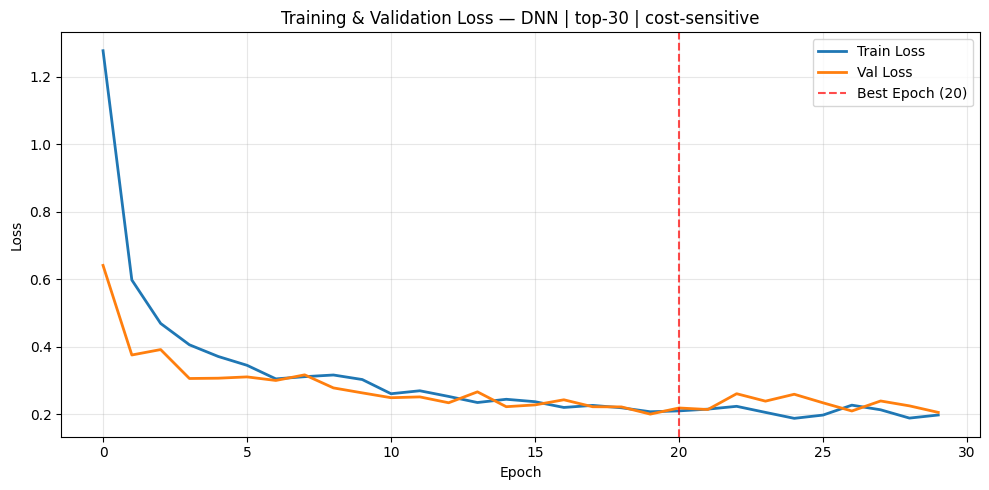

  Model saved: ../../models/dnn_top-30_cost-sensitive.pt

######################################################################
# Experiment: DNN | top-20 | baseline
######################################################################

 Training: DNN | top-20 | baseline
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.5393 | Val Loss: 0.1220 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0474 | Val Loss: 0.0345 | Patience: 2/10
  Epoch  20/100 | Train Loss: 0.0380 | Val Loss: 0.0457 | Patience: 6/10
  Epoch  30/100 | Train Loss: 0.0330 | Val Loss: 0.0375 | Patience: 7/10
  Epoch  40/100 | Train Loss: 0.0312 | Val Loss: 0.0236 | Patience: 1/10

  Early stopping at epoch 49
  Training time: 28.1s

  Macro F1 (PRIMARY):  0.9515
  Accuracy:            0.9946
  Macro Precision:     0.9703
  Macro Recall:        0.9361

  Saved: ../../figures/dnn_loss_top-20_baseline.png


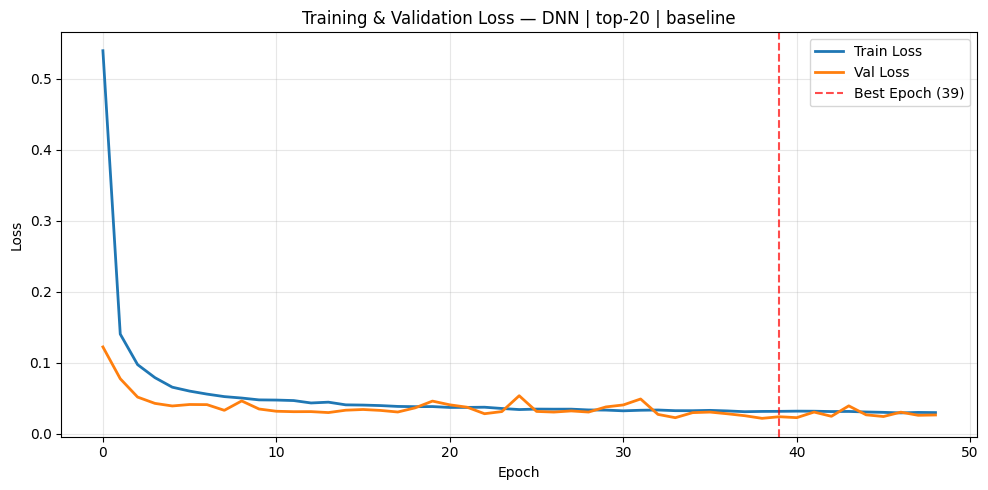

  Model saved: ../../models/dnn_top-20_baseline.pt

######################################################################
# Experiment: DNN | top-20 | smote
######################################################################
Applying SMOTE to training data...
  Before SMOTE: 98,493 samples


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples

 Training: DNN | top-20 | smote
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.2547 | Val Loss: 0.0421 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0849 | Val Loss: 0.0497 | Patience: 9/10

  Early stopping at epoch 11
  Training time: 50.9s

  Macro F1 (PRIMARY):  0.8837
  Accuracy:            0.9928
  Macro Precision:     0.8627
  Macro Recall:        0.9660

  Saved: ../../figures/dnn_loss_top-20_smote.png


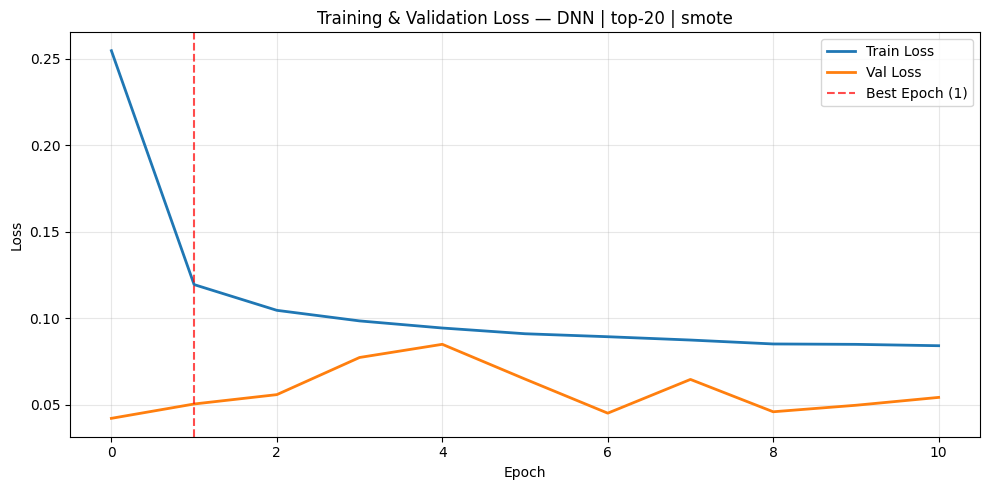

  Model saved: ../../models/dnn_top-20_smote.pt

######################################################################
# Experiment: DNN | top-20 | cost-sensitive
######################################################################
Computing class weights for cost-sensitive learning...
Class weights (higher = rarer class):
  Class 0: 1.3238
  Class 1: 19.2219
  Class 2: 0.1084
  Class 3: 2.4744
  Class 4: 273.5917
  Class 5: 373.0795
  Class 6: 5.1298
  Class 7: 10.2341
  Class 8: 3.9613
  Class 9: 5.1043
  Class 10: 1.2655
  Class 11: 40.6324

 Training: DNN | top-20 | cost-sensitive
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 1.2256 | Val Loss: 0.6081 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.3187 | Val Loss: 0.2905 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.2486 | Val Loss: 0.2634 | Patience: 5/10
  Epoch  30/100 | Train Loss: 0.1972 | Val Loss: 0.2440 | Patience: 1/10
  Epoch  40/100 | Train Loss: 0.1926 | Val Loss: 0.1859 | Patience: 3/10

  Early sto

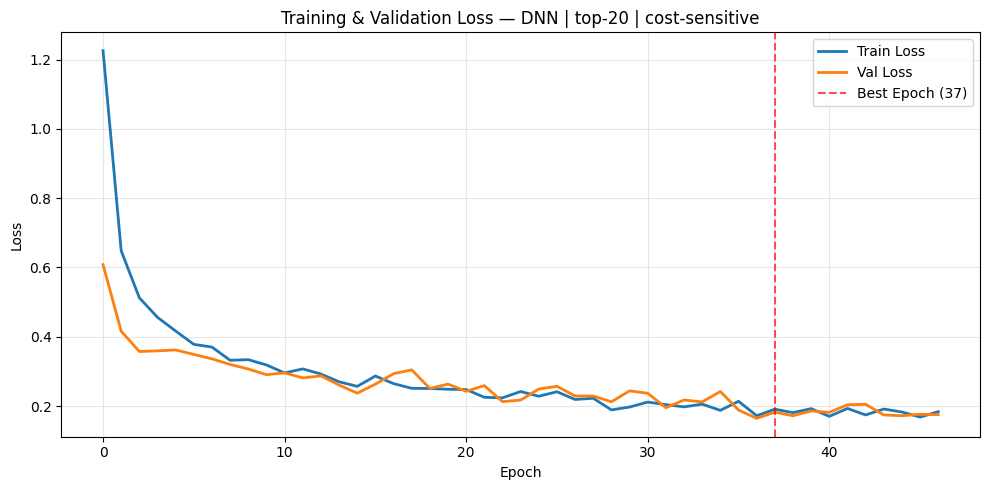

  Model saved: ../../models/dnn_top-20_cost-sensitive.pt

######################################################################
# Experiment: DNN | top-10 | baseline
######################################################################

 Training: DNN | top-10 | baseline
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.5492 | Val Loss: 0.1373 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0624 | Val Loss: 0.0354 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.0470 | Val Loss: 0.0317 | Patience: 1/10
  Epoch  30/100 | Train Loss: 0.0414 | Val Loss: 0.0302 | Patience: 4/10
  Epoch  40/100 | Train Loss: 0.0401 | Val Loss: 0.0275 | Patience: 0/10
  Epoch  50/100 | Train Loss: 0.0370 | Val Loss: 0.0271 | Patience: 2/10
  Epoch  60/100 | Train Loss: 0.0359 | Val Loss: 0.0255 | Patience: 2/10

  Early stopping at epoch 68
  Training time: 36.6s

  Macro F1 (PRIMARY):  0.7953
  Accuracy:            0.9919
  Macro Precision:     0.8073
  Macro Recall:        0.7873

  Saved: ../

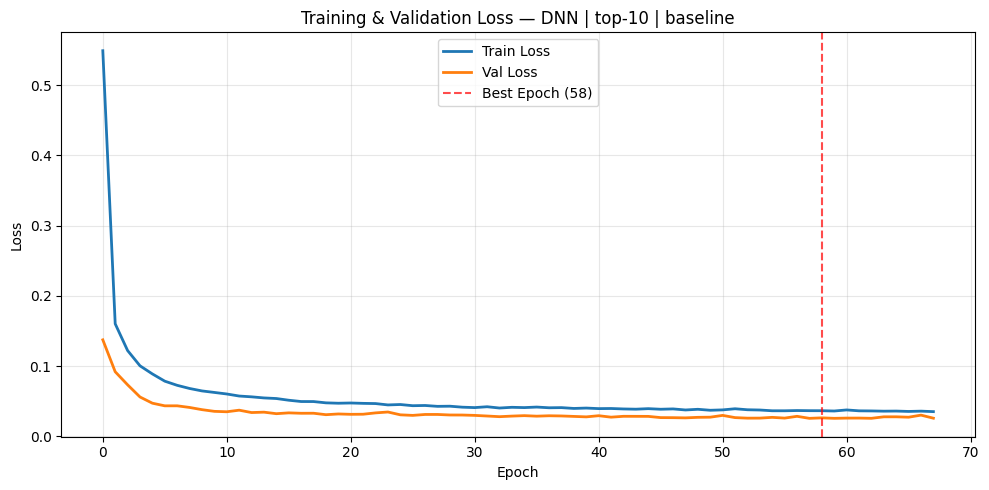

  Model saved: ../../models/dnn_top-10_baseline.pt

######################################################################
# Experiment: DNN | top-10 | smote
######################################################################
Applying SMOTE to training data...
  Before SMOTE: 98,493 samples
  After SMOTE:  908,724 samples

 Training: DNN | top-10 | smote
 Epochs: 100 | Patience: 10


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  Epoch   1/100 | Train Loss: 0.3578 | Val Loss: 0.0587 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.1419 | Val Loss: 0.0398 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.1324 | Val Loss: 0.0380 | Patience: 1/10
  Epoch  30/100 | Train Loss: 0.1275 | Val Loss: 0.0378 | Patience: 1/10
  Epoch  40/100 | Train Loss: 0.1258 | Val Loss: 0.0370 | Patience: 6/10
  Epoch  50/100 | Train Loss: 0.1238 | Val Loss: 0.0357 | Patience: 7/10

  Early stopping at epoch 53
  Training time: 241.1s

  Macro F1 (PRIMARY):  0.8390
  Accuracy:            0.9899
  Macro Precision:     0.8103
  Macro Recall:        0.9589

  Saved: ../../figures/dnn_loss_top-10_smote.png


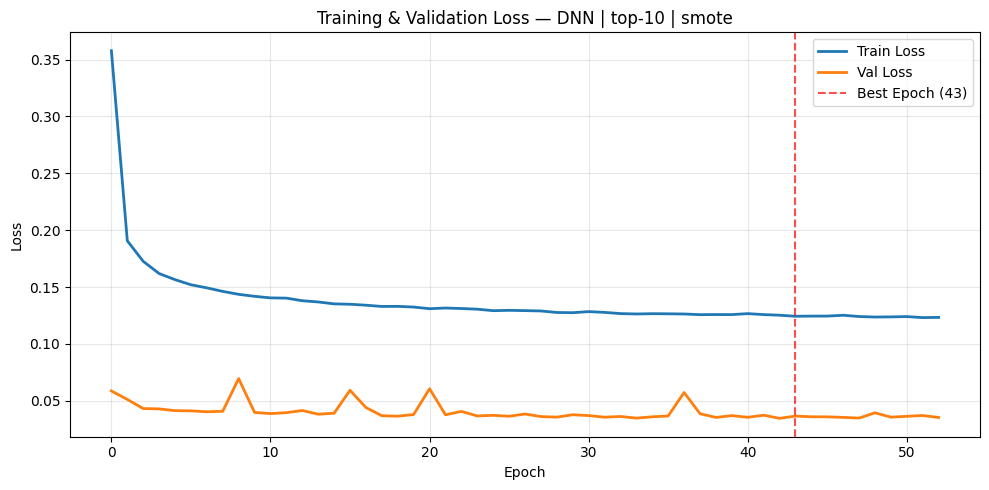

  Model saved: ../../models/dnn_top-10_smote.pt

######################################################################
# Experiment: DNN | top-10 | cost-sensitive
######################################################################
Computing class weights for cost-sensitive learning...
Class weights (higher = rarer class):
  Class 0: 1.3238
  Class 1: 19.2219
  Class 2: 0.1084
  Class 3: 2.4744
  Class 4: 273.5917
  Class 5: 373.0795
  Class 6: 5.1298
  Class 7: 10.2341
  Class 8: 3.9613
  Class 9: 5.1043
  Class 10: 1.2655
  Class 11: 40.6324

 Training: DNN | top-10 | cost-sensitive
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 1.3591 | Val Loss: 0.7836 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.4400 | Val Loss: 0.3459 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.3145 | Val Loss: 0.2749 | Patience: 0/10
  Epoch  30/100 | Train Loss: 0.2743 | Val Loss: 0.2747 | Patience: 7/10
  Epoch  40/100 | Train Loss: 0.2662 | Val Loss: 0.2910 | Patience: 4/10
  Epoch  50/

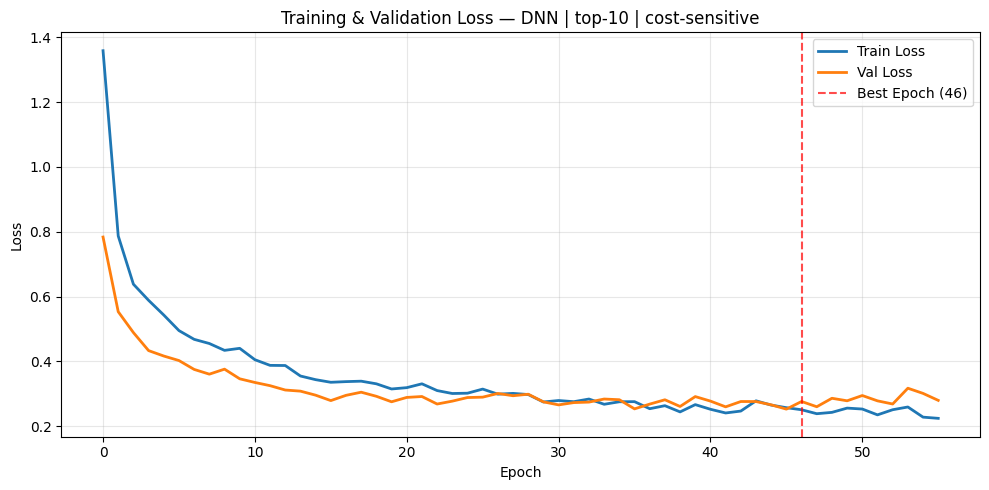

  Model saved: ../../models/dnn_top-10_cost-sensitive.pt

######################################################################
# Experiment: DNN | pca | baseline
######################################################################

 Training: DNN | pca | baseline
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.6101 | Val Loss: 0.1322 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0513 | Val Loss: 0.0503 | Patience: 3/10
  Epoch  20/100 | Train Loss: 0.0378 | Val Loss: 0.0450 | Patience: 3/10

  Early stopping at epoch 27
  Training time: 14.1s

  Macro F1 (PRIMARY):  0.8489
  Accuracy:            0.9935
  Macro Precision:     0.8710
  Macro Recall:        0.8378

  Saved: ../../figures/dnn_loss_pca_baseline.png


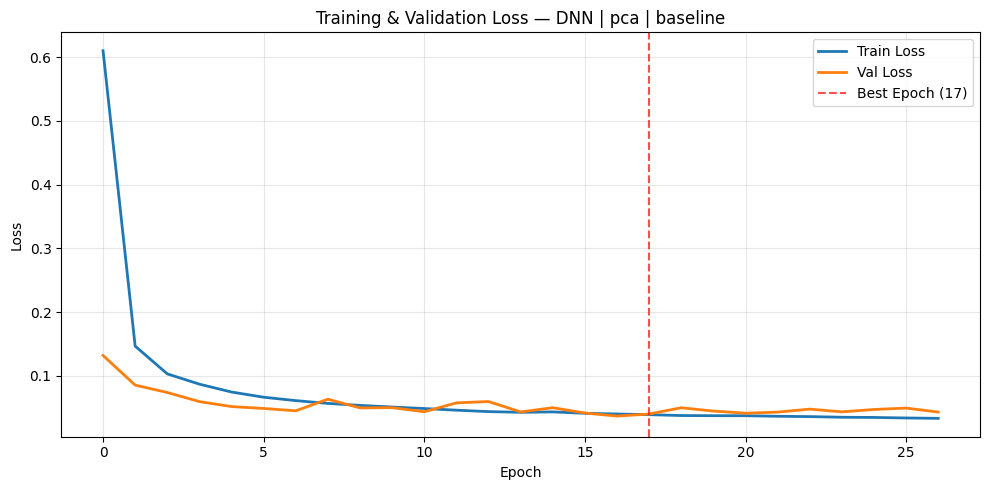

  Model saved: ../../models/dnn_pca_baseline.pt

######################################################################
# Experiment: DNN | pca | smote
######################################################################
Applying SMOTE to training data...
  Before SMOTE: 98,493 samples


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples

 Training: DNN | pca | smote
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 0.2610 | Val Loss: 0.0493 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.0772 | Val Loss: 0.0348 | Patience: 4/10
  Epoch  20/100 | Train Loss: 0.0693 | Val Loss: 0.0430 | Patience: 8/10

  Early stopping at epoch 22
  Training time: 102.2s

  Macro F1 (PRIMARY):  0.8824
  Accuracy:            0.9931
  Macro Precision:     0.8567
  Macro Recall:        0.9659

  Saved: ../../figures/dnn_loss_pca_smote.png


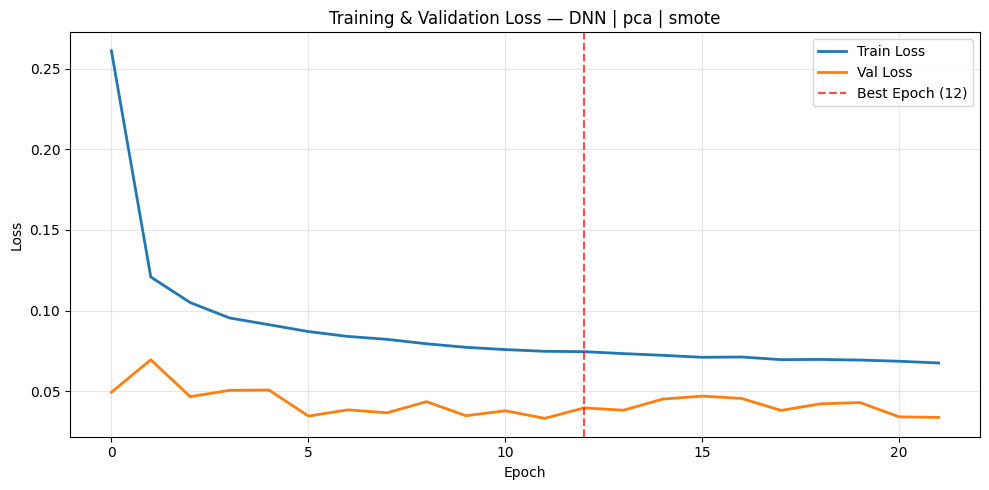

  Model saved: ../../models/dnn_pca_smote.pt

######################################################################
# Experiment: DNN | pca | cost-sensitive
######################################################################
Computing class weights for cost-sensitive learning...
Class weights (higher = rarer class):
  Class 0: 1.3238
  Class 1: 19.2219
  Class 2: 0.1084
  Class 3: 2.4744
  Class 4: 273.5917
  Class 5: 373.0795
  Class 6: 5.1298
  Class 7: 10.2341
  Class 8: 3.9613
  Class 9: 5.1043
  Class 10: 1.2655
  Class 11: 40.6324

 Training: DNN | pca | cost-sensitive
 Epochs: 100 | Patience: 10
  Epoch   1/100 | Train Loss: 1.2974 | Val Loss: 0.8095 | Patience: 0/10
  Epoch  10/100 | Train Loss: 0.3312 | Val Loss: 0.3528 | Patience: 0/10
  Epoch  20/100 | Train Loss: 0.2468 | Val Loss: 0.3000 | Patience: 5/10

  Early stopping at epoch 25
  Training time: 13.1s

  Macro F1 (PRIMARY):  0.8432
  Accuracy:            0.9844
  Macro Precision:     0.8038
  Macro Recall:        

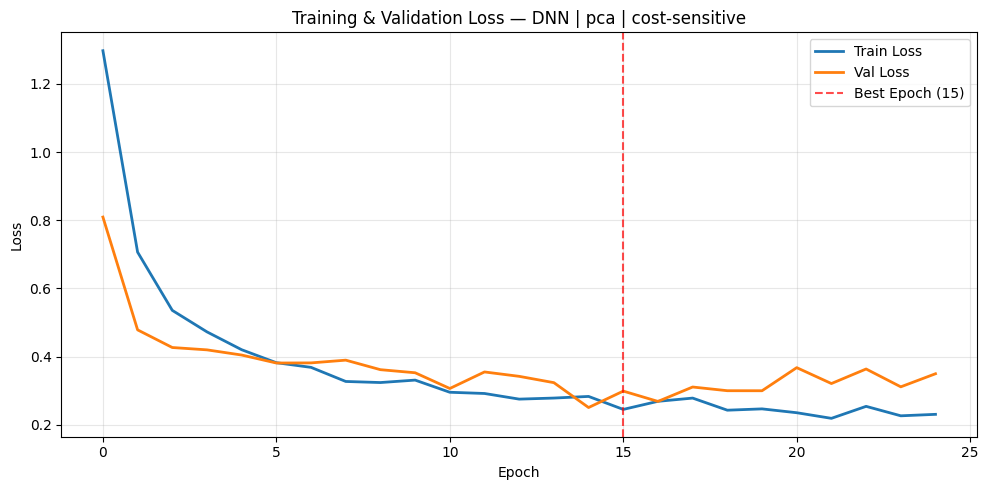

  Model saved: ../../models/dnn_pca_cost-sensitive.pt
  Saved report to ../../results/dnn_full-83_baseline_report.csv
  Saved summary to ../../results/dnn_full-83_baseline_summary.csv
  Saved report to ../../results/dnn_full-83_smote_report.csv
  Saved summary to ../../results/dnn_full-83_smote_summary.csv
  Saved report to ../../results/dnn_full-83_cost-sensitive_report.csv
  Saved summary to ../../results/dnn_full-83_cost-sensitive_summary.csv
  Saved report to ../../results/dnn_top-30_baseline_report.csv
  Saved summary to ../../results/dnn_top-30_baseline_summary.csv
  Saved report to ../../results/dnn_top-30_smote_report.csv
  Saved summary to ../../results/dnn_top-30_smote_summary.csv
  Saved report to ../../results/dnn_top-30_cost-sensitive_report.csv
  Saved summary to ../../results/dnn_top-30_cost-sensitive_summary.csv
  Saved report to ../../results/dnn_top-20_baseline_report.csv
  Saved summary to ../../results/dnn_top-20_baseline_summary.csv
  Saved report to ../../results/

In [55]:

# ## 7. Load Preprocessed Data & Run All 15 Experiments
#
# ⚠️ **WAIT**: Run this section only after Piyush has:
# 1. Saved preprocessed data to Drive (Phase 1)
# 2. Saved feature subsets to Drive (Phase 2)
#
# Update the file paths below to match your Drive/local setup.

# %%
# ============================================================
# UPDATE THESE PATHS to wherever Piyush saved the data
# ============================================================
DATA_DIR = "../../data/processed"  # or Google Drive path

# Load preprocessed data
# Uncomment and update when data is ready:

X_train_full = pd.read_pickle(f"{DATA_DIR}/X_train_scaled.pkl")
X_test_full = pd.read_pickle(f"{DATA_DIR}/X_test_scaled.pkl")
y_train = pd.read_pickle(f"{DATA_DIR}/y_train.pkl")
y_test = pd.read_pickle(f"{DATA_DIR}/y_test.pkl")
target_encoder = pd.read_pickle(f"{DATA_DIR}/target_encoder.pkl")
target_names = list(target_encoder.classes_)

# Feature subsets — uncomment when Piyush pushes them:
X_train_top10 = pd.read_pickle(f"{DATA_DIR}/X_train_top10.pkl")
X_test_top10 = pd.read_pickle(f"{DATA_DIR}/X_test_top10.pkl")
X_train_top20 = pd.read_pickle(f"{DATA_DIR}/X_train_top20.pkl")
X_test_top20 = pd.read_pickle(f"{DATA_DIR}/X_test_top20.pkl")
X_train_top30 = pd.read_pickle(f"{DATA_DIR}/X_train_top30.pkl")
X_test_top30 = pd.read_pickle(f"{DATA_DIR}/X_test_top30.pkl")
X_train_pca = pd.read_pickle(f"{DATA_DIR}/X_train_pca.pkl")
X_test_pca = pd.read_pickle(f"{DATA_DIR}/X_test_pca.pkl")

print(f"Full feature set: {X_train_full.shape[1]} features")
print(f"Target classes: {target_names}")

# %%
# ============================================================
# RUN ALL 15 EXPERIMENTS
# ============================================================
# Uncomment this block when data is loaded above

feature_sets = {
    "full-83": (X_train_full, X_test_full),
    "top-30": (X_train_top30, X_test_top30),
    "top-20": (X_train_top20, X_test_top20),
    "top-10": (X_train_top10, X_test_top10),
    "pca": (X_train_pca, X_test_pca),
}

imbalance_strategies = ["baseline", "smote", "cost-sensitive"]

all_results = []

for fs_name, (X_tr, X_te) in feature_sets.items():
    for strategy in imbalance_strategies:
        result = run_single_experiment(
            X_train=X_tr,
            y_train=y_train,
            X_test=X_te,
            y_test=y_test,
            feature_set_name=fs_name,
            imbalance_strategy=strategy,
            target_names=target_names,
            num_epochs=100,
            patience=10,
            lr=0.001,
            dropout=0.3,
            batch_size=256,
        )
        all_results.append(result)

# # Save all results
for r in all_results:
    name = f"dnn_{r['feature_set']}_{r['imbalance_strategy']}"
    save_results(r, name, save_dir="../../results")
print("\nAll 15 DNN experiments complete!")

In [56]:
results_dir = "../../results"
summaries = []
for f in sorted(os.listdir(results_dir)):
    if f.endswith("_summary.csv"):
        df = pd.read_csv(os.path.join(results_dir, f))
        summaries.append(df)

all_results_df = pd.concat(summaries, ignore_index=True)
print(all_results_df.to_string(index=False))

                experiment  macro_f1  accuracy  macro_precision  macro_recall
      dnn_full-83_baseline  0.790888  0.994193         0.811570      0.776809
dnn_full-83_cost-sensitive  0.870545  0.992487         0.832698      0.968602
         dnn_full-83_smote  0.867933  0.994355         0.838221      0.969584
          dnn_pca_baseline  0.848888  0.993543         0.871014      0.837846
    dnn_pca_cost-sensitive  0.843174  0.984405         0.803837      0.947706
             dnn_pca_smote  0.882447  0.993096         0.856658      0.965855
       dnn_top-10_baseline  0.795295  0.991878         0.807310      0.787279
 dnn_top-10_cost-sensitive  0.819127  0.986274         0.783412      0.946277
          dnn_top-10_smote  0.839028  0.989929         0.810319      0.958889
       dnn_top-20_baseline  0.951497  0.994558         0.970280      0.936111
 dnn_top-20_cost-sensitive  0.899307  0.990822         0.864080      0.952790
          dnn_top-20_smote  0.883652  0.992812         0.862659 

In [ ]:
# ## 8. Quick Results Summary
#
# Uncomment after running experiments above.

# %%
results_df = pd.read_csv("../../results/mahip_results.csv")
print(results_df.sort_values("macro_f1", ascending=False).to_string(index=False))



 BEFORE SMOTE
 Total samples: 98,493
Class                             Count        %  Bar
-----------------------------------------------------------------
2                                75,727   76.89%  ██████████████████████████████████████
10                                6,486    6.59%  ███
0                                 6,200    6.29%  ███
3                                 3,317    3.37%  █
8                                 2,072    2.10%  █
9                                 1,608    1.63%  
6                                 1,600    1.62%  
7                                   802    0.81%  
1                                   427    0.43%  
11                                  202    0.21%  
4                                    30    0.03%  
5                                    22    0.02%  
-----------------------------------------------------------------
Unique classes:                12

  Before SMOTE: 98,493 samples


/Users/mahip/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples

 AFTER SMOTE
 Total samples: 908,724
Class                             Count        %  Bar
-----------------------------------------------------------------
2                                75,727    8.33%  ████
6                                75,727    8.33%  ████
10                               75,727    8.33%  ████
3                                75,727    8.33%  ████
8                                75,727    8.33%  ████
0                                75,727    8.33%  ████
9                                75,727    8.33%  ████
7                                75,727    8.33%  ████
1                                75,727    8.33%  ████
4                                75,727    8.33%  ████
11                               75,727    8.33%  ████
5                                75,727    8.33%  ████
-----------------------------------------------------------------
Unique classes:                12



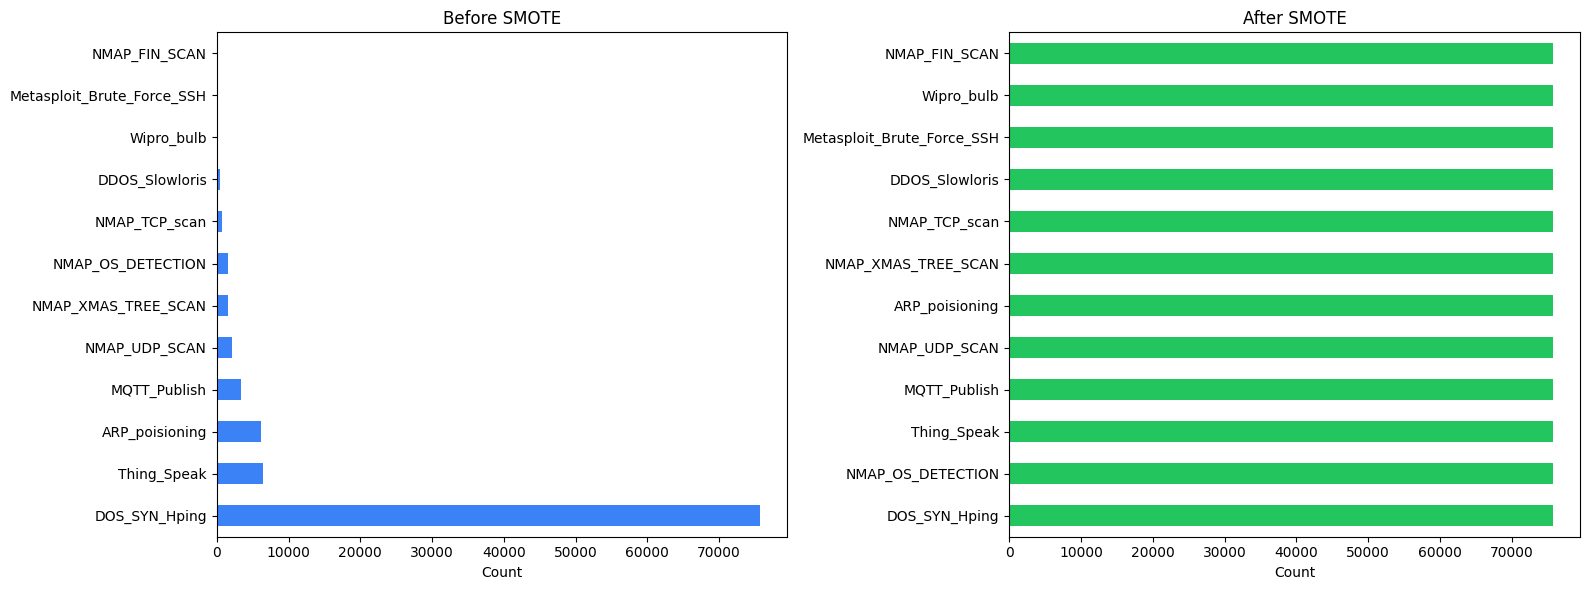

In [52]:

# ## 9. SMOTE Before/After Comparison (for report Figure)
#
# Run this to generate the before/after class distribution figure.

# %%
from src.data_loader import print_class_distribution

print_class_distribution(pd.Series(y_train), title="BEFORE SMOTE")
X_smote, y_smote = apply_smote(X_train_full, y_train)
print_class_distribution(pd.Series(y_smote), title="AFTER SMOTE")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pd.Series(y_train).map(dict(enumerate(target_names))).value_counts().plot(
    kind="barh", ax=axes[0], color="#3b82f6"
)
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Count")

pd.Series(y_smote).map(dict(enumerate(target_names))).value_counts().plot(
    kind="barh", ax=axes[1], color="#22c55e"
)
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig("../../figures/smote_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
results_dir = "../../results"
for f in sorted(os.listdir(results_dir)):
    if f.endswith("_report.csv"):
        print(f"\n{'='*60}")
        print(f"  {f.replace('_report.csv', '')}")
        print(f"{'='*60}")
        df = pd.read_csv(os.path.join(results_dir, f), index_col=0)
        class_rows = df.iloc[:12][['precision', 'recall', 'f1-score', 'support']]
        print(class_rows.to_string())


  dnn_full-83_baseline
    precision    recall  f1-score  support
0    0.967578  0.981935  0.974704   1550.0
1    1.000000  0.803738  0.891192    107.0
2    1.000000  1.000000  1.000000  18932.0
3    1.000000  0.996381  0.998187    829.0
4    0.000000  0.000000  0.000000      7.0
5    0.833333  0.833333  0.833333      6.0
6    0.992556  1.000000  0.996264    400.0
7    0.995025  1.000000  0.997506    200.0
8    0.958647  0.984556  0.971429    518.0
9    1.000000  0.995025  0.997506    402.0
10   0.978488  0.981504  0.979994   1622.0
11   1.000000  0.745098  0.853933     51.0

  dnn_full-83_cost-sensitive
    precision    recall  f1-score  support
0    0.944123  0.948387  0.946250   1550.0
1    0.736111  0.990654  0.844622    107.0
2    0.999947  1.000000  0.999974  18932.0
3    0.995175  0.995175  0.995175    829.0
4    0.200000  1.000000  0.333333      7.0
5    0.357143  0.833333  0.500000      6.0
6    0.992556  1.000000  0.996264    400.0
7    0.966184  1.000000  0.982801    200.0


In [54]:
for f in sorted(os.listdir(results_dir)):
    if f.endswith("_report.csv"):
        name = f.replace("_report.csv", "")
        df = pd.read_csv(os.path.join(results_dir, f), index_col=0)
        row4 = df.iloc[4]  # Metasploit_Brute_Force_SSH
        row5 = df.iloc[5]  # NMAP_FIN_SCAN
        print(f"\n{name}")
        print(f"  Metasploit_Brute_Force_SSH: precision={row4['precision']:.3f}  recall={row4['recall']:.3f}  f1={row4['f1-score']:.3f}")
        print(f"  NMAP_FIN_SCAN:              precision={row5['precision']:.3f}  recall={row5['recall']:.3f}  f1={row5['f1-score']:.3f}")


dnn_full-83_baseline
  Metasploit_Brute_Force_SSH: precision=0.000  recall=0.000  f1=0.000
  NMAP_FIN_SCAN:              precision=0.833  recall=0.833  f1=0.833

dnn_full-83_cost-sensitive
  Metasploit_Brute_Force_SSH: precision=0.200  recall=1.000  f1=0.333
  NMAP_FIN_SCAN:              precision=0.357  recall=0.833  f1=0.500

dnn_full-83_smote
  Metasploit_Brute_Force_SSH: precision=0.233  recall=1.000  f1=0.378
  NMAP_FIN_SCAN:              precision=0.625  recall=0.833  f1=0.714
